# Exploratory Data Analysis (EDA)

## Project: Smart College Analysis and Prediction System

The objective of this EDA is to analyze student academic data to identify
patterns, relationships, and key factors influencing student performance.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [2]:
df = pd.read_csv("student_data.csv")
df.head()

,attendance,midsem,assignment,gpa,quiz,result
0,51,14,2,1.0,5,1
1,92,13,0,4.2,3,1
2,14,7,3,7.7,1,0
3,71,9,0,0.8,5,0
4,60,8,1,0.4,5,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   attendance  10000 non-null  int64  
 1   midsem      10000 non-null  int64  
 2   assignment  10000 non-null  int64  
 3   gpa         10000 non-null  float64
 4   quiz        10000 non-null  int64  
 5   result      10000 non-null  int64  
dtypes: float64(1), int64(5)
memory usage: 468.9 KB


In [4]:
df.describe()

,attendance,midsem,assignment,gpa,quiz,result
count,10000.0000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,49.8988,10.158000,2.505700,5.047520,2.503300,0.504700
std,29.1995,6.054808,1.703132,2.886498,1.696961,0.500003
min,0.0000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,24.0000,5.000000,1.000000,2.600000,1.000000,0.000000
50%,50.0000,10.000000,3.000000,5.100000,3.000000,1.000000
75%,75.0000,15.000000,4.000000,7.600000,4.000000,1.000000
max,100.0000,20.000000,5.000000,10.000000,5.000000,1.000000


In [5]:
df.isnull().sum()

attendance    0
midsem        0
assignment    0
gpa           0
quiz          0
result        0
dtype: int64

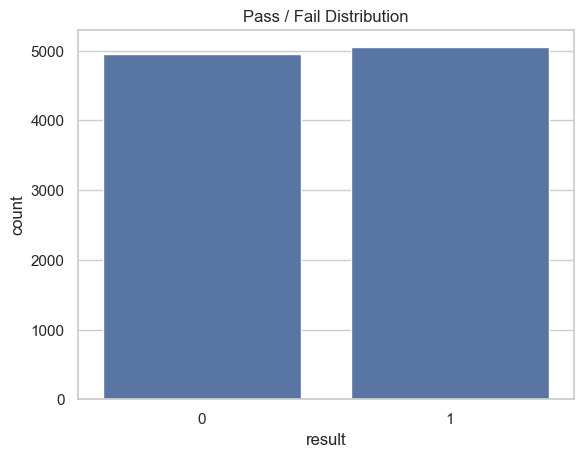

In [6]:
sns.countplot(x="result", data=df)
plt.title("Pass / Fail Distribution")
plt.show()

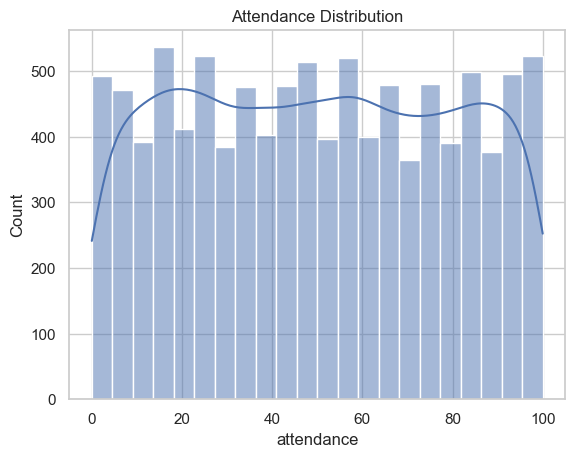

In [7]:
sns.histplot(df["attendance"], kde=True)
plt.title("Attendance Distribution")
plt.show()

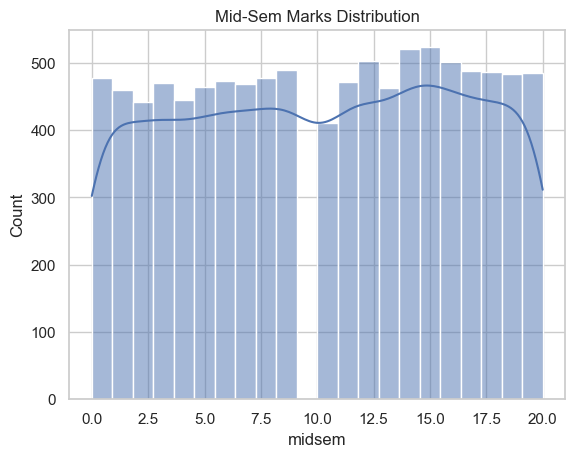

In [8]:
sns.histplot(df["midsem"], kde=True)
plt.title("Mid-Sem Marks Distribution")
plt.show()

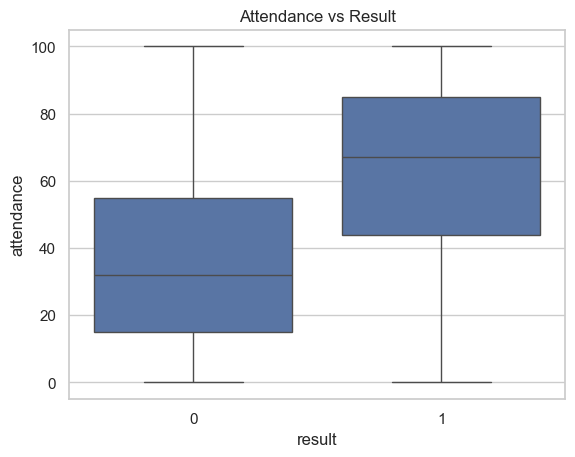

In [9]:
sns.boxplot(x="result", y="attendance", data=df)
plt.title("Attendance vs Result")
plt.show()

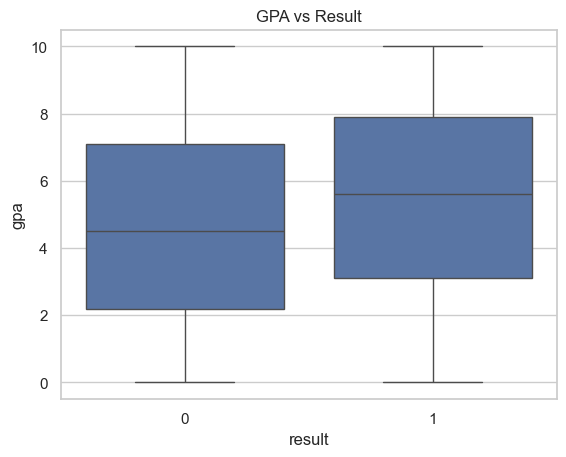

In [10]:
sns.boxplot(x="result", y="gpa", data=df)
plt.title("GPA vs Result")
plt.show()

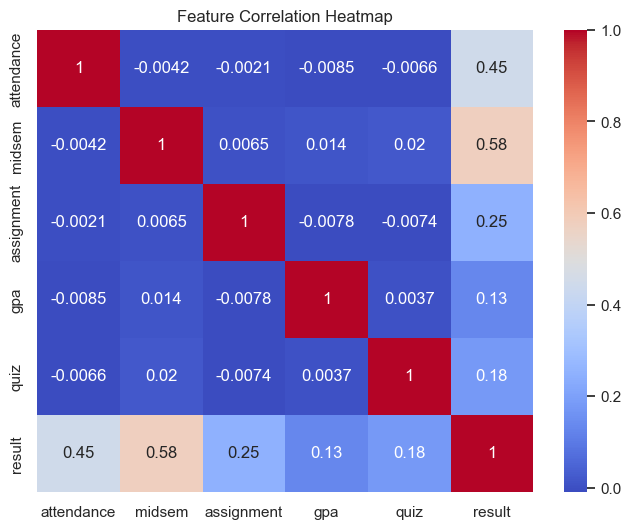

In [11]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

In [12]:
import pandas as pd
import numpy as np
import pickle
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# ── 1. Load corrected dataset ─────────────────────────────────────
df = pd.read_csv("student_data.csv")
print("✅ Dataset loaded!")
print("Shape:", df.shape)
print("\nLabel counts:")
print(df['result'].value_counts())
print("\nMin/Max per column:")
print(df.describe().loc[['min','max']].round(2))

# ── 2. Features & Label ───────────────────────────────────────────
X = df[['attendance', 'midsem', 'assignment', 'gpa', 'quiz']]
y = df['result']

# ── 3. Train/Test Split ───────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain size: {len(X_train)} | Test size: {len(X_test)}")

# ── 4. Train Model ────────────────────────────────────────────────
model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)
model.fit(X_train, y_train)
print("\n✅ Model trained!")

# ── 5. Evaluate ───────────────────────────────────────────────────
y_pred = model.predict(X_test)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ── 6. Test weak vs strong student ───────────────────────────────
print("Manual Test Predictions:")
test_cases = [
    [20,  6,  1, 3.0,  1],   # weak   → should be ❌ Fail
    [50, 10,  2, 5.0,  2],   # medium → borderline
    [85, 16,  4, 8.0,  4],   # strong → should be ✅ Pass
    [10,  2,  0, 1.0,  0],   # very weak → ❌ Fail
]
for case in test_cases:
    pred = model.predict([case])[0]
    score = (
        (case[0]/100)*30 + (case[1]/20)*35 +
        (case[2]/5)*15   + (case[4]/5)*10  +
        (case[3]/10)*10
    )
    print(f"  {case} → Score:{score:.1f} → {'✅ Pass' if pred==1 else '❌ Fail'}")

# ── 7. Save new model ─────────────────────────────────────────────
pickle.dump(model, open("../artifacts/model.pkl", "wb"))
print("\n✅ New model saved to artifacts/model.pkl!")

✅ Dataset loaded!
Shape: (10000, 6)

Label counts:
result
1    5047
0    4953
Name: count, dtype: int64

Min/Max per column:
     attendance  midsem  assignment   gpa  quiz  result
min         0.0     0.0         0.0   0.0   0.0     0.0
max       100.0    20.0         5.0  10.0   5.0     1.0

Train size: 8000 | Test size: 2000

✅ Model trained!

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.92      0.92       991
           1       0.92      0.92      0.92      1009

    accuracy                           0.92      2000
   macro avg       0.92      0.92      0.92      2000
weighted avg       0.92      0.92      0.92      2000

Manual Test Predictions:
  [20, 6, 1, 3.0, 1] → Score:24.5 → ❌ Fail
  [50, 10, 2, 5.0, 2] → Score:47.5 → ❌ Fail
  [85, 16, 4, 8.0, 4] → Score:81.5 → ✅ Pass
  [10, 2, 0, 1.0, 0] → Score:7.5 → ❌ Fail

✅ New model saved to artifacts/model.pkl!


d:\College_Dashboard\venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
d:\College_Dashboard\venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
d:\College_Dashboard\venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
d:\College_Dashboard\venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


## Key Insights from EDA

1. Attendance has a strong influence on student performance.
2. GPA and internal marks are positively correlated with final result.
3. Low attendance and low scores increase failure probability.
4. No missing values were found in the dataset.
5. Features are suitable for classification models.

## Conclusion

EDA helped identify the most influential academic factors affecting
student performance. These insights guided feature selection and
model choice for the prediction system.